In [1]:
import os 
import pandas as pd 
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [2]:
from MisC.utility import *

In [3]:
os.chdir("/work/DPDS/s205711/yunguan")

In [4]:
cell_by_gene_path = "./data/merscope/cell_by_gene.csv"
detected_transcripts_path = './data/merscope/detected_transcripts.csv'
cell_metadata_path = './data/merscope/cell_metadata.csv'
cell_boundaries_path = "./data/merscope/cell_boundaries.parquet"

In [5]:
adata, cell_coords, tx_metadata = import_data(cell_by_gene_counts=cell_by_gene_path,
                                              cell_metadata=cell_metadata_path,
                                              cell_boundary_polygons=cell_boundaries_path,
                                              detected_transcripts=detected_transcripts_path)

Successfully read in data. Performing basic transformation
UMAP


/home2/s205711/.conda/envs/yunguan/lib/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 400 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/home2/s205711/.conda/envs/yunguan/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Leiden
Done~


In [6]:
mask_distance = calculate_mask_distance(adata=adata, 
                                        cell_coords=cell_coords)

In [7]:
mask_distance

,cell_id,neighbor_by_centroid,mask_distance,x,y,centroid_geom
0,cell_125,cell_130,5.302726,5141.449240,333.655035,POINT (5141.449 333.655)
1,cell_125,cell_213,0.116961,5141.449240,333.655035,POINT (5141.449 333.655)
2,cell_126,cell_213,0.107858,5127.024056,338.492502,POINT (5127.024 338.493)
3,cell_129,cell_137,0.086638,5088.117941,345.988588,POINT (5088.118 345.989)
4,cell_130,cell_125,5.302726,5151.031245,344.655966,POINT (5151.031 344.656)
...,...,...,...,...,...,...
113775,cell_81800,cell_81758,2.522293,2161.964856,3053.171049,POINT (2161.965 3053.171)
113776,cell_81800,cell_81796,2.642228,2161.964856,3053.171049,POINT (2161.965 3053.171)
113777,cell_81801,cell_81751,0.167347,2167.587566,3058.622130,POINT (2167.588 3058.622)
113778,cell_81802,cell_81756,0.265036,2073.113570,3074.149241,POINT (2073.114 3074.149)


In [8]:
interface = mask_distance[mask_distance.mask_distance<=1]
# We extract transcripts of those interface cells 
intf_tx = tx_metadata[tx_metadata.cell_id.isin(interface.cell_id)][["global_x","global_y",
                                                                    "cell_id","gene",
                                                                    "Geometry"]]
intf_tx.columns = ['x','y','cell_id','gene','tx_geom']
intf_tx.reset_index(inplace=True)
# Then we compute the distance between transcript and cell mask of neighboring cell
intf_tx = intf_tx.merge(interface[['cell_id','neighbor_by_centroid','mask_distance', 'centroid_geom']], on='cell_id')



In [9]:
intf_tx

,molecule_id,x,y,cell_id,gene,tx_geom,neighbor_by_centroid,mask_distance,centroid_geom
0,m2,396.88130,2964.4827,cell_51489,ADH1B,POINT (396.881 2964.483),cell_51432,0.107846,POINT (401.664 2970.195)
1,m3,396.86328,2966.5442,cell_51489,ADH1B,POINT (396.863 2966.544),cell_51432,0.107846,POINT (401.664 2970.195)
2,m4,384.44330,2958.4440,cell_51435,CCL21,POINT (384.443 2958.444),cell_51440,0.268748,POINT (384.398 2962.417)
3,m6,386.82483,2960.2285,cell_51435,BAAT,POINT (386.825 2960.228),cell_51440,0.268748,POINT (384.398 2962.417)
4,m7,380.56780,2963.8887,cell_51435,BRD2,POINT (380.568 2963.889),cell_51440,0.268748,POINT (384.398 2962.417)
...,...,...,...,...,...,...,...,...,...
11578338,m7077008,14339.99400,2281.0450,cell_51304,VCAM1,POINT (14339.994 2281.045),cell_51027,0.107816,POINT (14335.075 2283.95)
11578339,m7077008,14339.99400,2281.0450,cell_51304,VCAM1,POINT (14339.994 2281.045),cell_51053,0.107868,POINT (14335.075 2283.95)
11578340,m7077009,14318.59000,2313.1724,cell_51078,VPS37B,POINT (14318.59 2313.172),cell_51313,0.107875,POINT (14319.134 2308.641)
11578341,m7077011,14339.72700,2292.8303,cell_51062,ZC3HAV1,POINT (14339.727 2292.83),cell_51053,0.108000,POINT (14330.785 2294.886)


In [10]:
intf_tx['mask_geom'] = cell_coords.loc[intf_tx.neighbor_by_centroid.values, "Geometry"].values

In [11]:
intf_tx['tx_mask_distance'] = distance(intf_tx['tx_geom'], intf_tx['mask_geom'])
intf_tx['tx_centroid_distance'] = distance(intf_tx['tx_geom'], intf_tx['centroid_geom'])
intf_tx['celltype'] = adata.obs.loc[intf_tx.cell_id, "leiden"].values
intf_tx['neighbor_celltype'] = adata.obs.loc[intf_tx.neighbor_by_centroid, "leiden"].values

In [21]:
(intf_tx['tx_centroid_distance']/(intf_tx['tx_centroid_distance'] + intf_tx['tx_mask_distance']-intf_tx['mask_distance']))

3.504560313659039e-05

In [12]:
intf_tx

,molecule_id,x,y,cell_id,gene,tx_geom,neighbor_by_centroid,mask_distance,centroid_geom,mask_geom,tx_mask_distance,tx_centroid_distance,celltype,neighbor_celltype
0,m2,396.88130,2964.4827,cell_51489,ADH1B,POINT (396.881 2964.483),cell_51432,0.107846,POINT (401.664 2970.195),"MULTIPOLYGON (((403.089 2964.304, 403.61 2963....",1.761114,7.450500,0,2
1,m3,396.86328,2966.5442,cell_51489,ADH1B,POINT (396.863 2966.544),cell_51432,0.107846,POINT (401.664 2970.195),"MULTIPOLYGON (((403.089 2964.304, 403.61 2963....",3.718856,6.031496,0,2
2,m4,384.44330,2958.4440,cell_51435,CCL21,POINT (384.443 2958.444),cell_51440,0.268748,POINT (384.398 2962.417),"MULTIPOLYGON (((369.269 2976.301, 371.378 2977...",10.095158,3.973289,0,2
3,m6,386.82483,2960.2285,cell_51435,BAAT,POINT (386.825 2960.228),cell_51440,0.268748,POINT (384.398 2962.417),"MULTIPOLYGON (((369.269 2976.301, 371.378 2977...",10.121990,3.267813,0,2
4,m7,380.56780,2963.8887,cell_51435,BRD2,POINT (380.568 2963.889),cell_51440,0.268748,POINT (384.398 2962.417),"MULTIPOLYGON (((369.269 2976.301, 371.378 2977...",3.527638,4.103309,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11578338,m7077008,14339.99400,2281.0450,cell_51304,VCAM1,POINT (14339.994 2281.045),cell_51027,0.107816,POINT (14335.075 2283.95),"MULTIPOLYGON (((14332.768 2279.594, 14334.992 ...",1.925136,5.713153,1,0
11578339,m7077008,14339.99400,2281.0450,cell_51304,VCAM1,POINT (14339.994 2281.045),cell_51053,0.107868,POINT (14335.075 2283.95),"MULTIPOLYGON (((14340.935 2291.54, 14340.596 2...",5.880257,5.713153,1,2
11578340,m7077009,14318.59000,2313.1724,cell_51078,VPS37B,POINT (14318.59 2313.172),cell_51313,0.107875,POINT (14319.134 2308.641),"MULTIPOLYGON (((14306.319 2324.416, 14310.578 ...",2.632515,4.564371,4,1
11578341,m7077011,14339.72700,2292.8303,cell_51062,ZC3HAV1,POINT (14339.727 2292.83),cell_51053,0.108000,POINT (14330.785 2294.886),"MULTIPOLYGON (((14340.935 2291.54, 14340.596 2...",1.080734,9.174957,1,2


In [22]:
intf_tx = annotate_tx_mask_distance(adata=adata, 
                                    tx_metadata=tx_metadata,
                                    cell_coords=cell_coords,
                                    mask_distance=mask_distance)

In [23]:
layer = "counts_0"

In [109]:
sample1 = adata.to_df(layer).groupby(adata.obs.leiden, 
                           observed=True, 
                           as_index=False).apply(lambda x: x.sample(1000, replace=True)).reset_index(drop=False,
                                                                                    names=['leiden', 'cell_id']).drop(columns=['cell_id'])
sample2 = adata.to_df(layer).groupby(adata.obs.leiden, 
                           observed=True, 
                           as_index=False).apply(lambda x: x.sample(1000, replace=True)).reset_index(drop=False,
                                                                                    names=['leiden', 'cell_id']).drop(columns=['cell_id'])

In [110]:
counts1 = sample1.groupby(by=['leiden'], observed=True, as_index=False).sum()
counts2 = sample2.groupby(by=['leiden'], observed=True, as_index=False).sum()

In [111]:
count_df = pd.concat([counts1, counts2], axis=0).reset_index(drop=True)

In [112]:
count_df["sample_id"] = "Sample"+count_df.index.astype(str)

In [113]:
metadata = count_df[["sample_id", "leiden"]]

In [114]:
metadata.set_index("sample_id", inplace=True)

In [116]:
count_df.drop(columns=['leiden'], inplace=True)

In [117]:
count_df.set_index('sample_id', inplace=True)

In [118]:
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=count_df,
    metadata=metadata,
    design_factors="leiden",
    refit_cooks=True,
    inference=inference,
)


In [119]:
dds.deseq2()

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.08 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.09 seconds.

Fitting LFCs...
... done in 0.08 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.



In [136]:
from itertools import permutations
for c1, c2 in permutations([1,2,3,4,5], 2):
    print(str(c1) + "_" + str(c2))

1_2
1_3
1_4
1_5
2_1
2_3
2_4
2_5
3_1
3_2
3_4
3_5
4_1
4_2
4_3
4_5
5_1
5_2
5_3
5_4


In [120]:
stat_res = DeseqStats(dds, inference=inference, contrast=['leiden', "0",'3'],
                      quiet=True)

In [121]:
stat_res.summary()

In [137]:
stat_res.results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ACTA2,150.968009,-2.024469,0.153968,-13.148598,1.733591e-39,1.284142e-38
ACTG2,26.260973,0.851431,0.350068,2.432187,1.500797e-02,2.470448e-02
ADAM12,25.737475,0.055669,0.353194,0.157617,8.747589e-01,8.961298e-01
ADAM28,54.584613,0.811850,0.251837,3.223709,1.265421e-03,2.457128e-03
ADGRE5,173.551744,-2.269313,0.164030,-13.834741,1.573020e-43,1.258416e-42
...,...,...,...,...,...,...
YPEL5,241.955690,0.688501,0.122902,5.602019,2.118691e-08,6.231444e-08
ZBTB16,377.230686,1.919132,0.102786,18.671167,8.497497e-78,9.997056e-77
ZC3HAV1,121.440988,0.316429,0.174038,1.818155,6.904039e-02,9.898263e-02
ZFP36L1,40.929558,-0.262429,0.311587,-0.842236,3.996561e-01,4.620302e-01


In [135]:
((stat_res.results_df['padj'] <= 0.05) & (stat_res.results_df['log2FoldChange']>1)).sum()

71

In [138]:
stat_res = DeseqStats(dds, inference=inference, contrast=['leiden', "3",'0'],
                      quiet=True)
stat_res.summary()

In [139]:
stat_res.results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ACTA2,150.968009,2.024469,0.153968,13.148598,1.733591e-39,1.284142e-38
ACTG2,26.260973,-0.851431,0.350068,-2.432187,1.500797e-02,2.470448e-02
ADAM12,25.737475,-0.055669,0.353194,-0.157617,8.747589e-01,8.961298e-01
ADAM28,54.584613,-0.811850,0.251837,-3.223709,1.265421e-03,2.457128e-03
ADGRE5,173.551744,2.269313,0.164030,13.834741,1.573020e-43,1.258416e-42
...,...,...,...,...,...,...
YPEL5,241.955690,-0.688501,0.122902,-5.602019,2.118691e-08,6.231444e-08
ZBTB16,377.230686,-1.919132,0.102786,-18.671167,8.497497e-78,9.997056e-77
ZC3HAV1,121.440988,-0.316429,0.174038,-1.818155,6.904039e-02,9.898263e-02
ZFP36L1,40.929558,0.262429,0.311587,0.842236,3.996561e-01,4.620302e-01


In [89]:
s_total = adata.to_df(layer).groupby(adata.obs.leiden, observed=True).count()
s_above_0 = (adata.to_df(layer)>0).groupby(adata.obs.leiden, observed=True).sum()
percent_pos = s_above_0 / s_total

In [150]:
rna_to_rm_df = []

In [151]:
for neighbor_celltype, celltype in permutations(percent_pos.index, 2):
    diff_percent = percent_pos.loc[neighbor_celltype, :] - percent_pos.loc[celltype,:]
    rna_to_rm = list(diff_percent.index[diff_percent>0.25])
    rna_to_rm_df.append([celltype, neighbor_celltype, rna_to_rm])

In [160]:
temp

,celltype,neighbor_celltype,gene,to_remove
0,1,0,BRD2,True
0,1,0,FOS,True
0,1,0,FOSB,True
0,1,0,PSAP,True
0,1,0,RORA,True
...,...,...,...,...
41,5,6,KLF6,True
41,5,6,NFKBIZ,True
41,5,6,PPP1R15A,True
41,5,6,SPP1,True


In [159]:
temp = pd.DataFrame(rna_to_rm_df, columns=['celltype', "neighbor_celltype", "gene"]).explode(column='gene')
temp['to_remove'] = True
intf_tx.merge(temp, how="left", on=['celltype', "neighbor_celltype", "gene"]).fillna(False)


,molecule_id,x,y,cell_id,gene,tx_geom,neighbor_by_centroid,mask_distance,mask_geom,tx_mask_distance,celltype,neighbor_celltype,to_remove
0,m2,396.88130,2964.4827,cell_51489,ADH1B,POINT (396.881 2964.483),cell_51432,0.107846,"MULTIPOLYGON (((403.089 2964.304, 403.61 2963....",1.761114,0,2,False
1,m3,396.86328,2966.5442,cell_51489,ADH1B,POINT (396.863 2966.544),cell_51432,0.107846,"MULTIPOLYGON (((403.089 2964.304, 403.61 2963....",3.718856,0,2,False
2,m4,384.44330,2958.4440,cell_51435,CCL21,POINT (384.443 2958.444),cell_51440,0.268748,"MULTIPOLYGON (((369.269 2976.301, 371.378 2977...",10.095158,0,2,False
3,m6,386.82483,2960.2285,cell_51435,BAAT,POINT (386.825 2960.228),cell_51440,0.268748,"MULTIPOLYGON (((369.269 2976.301, 371.378 2977...",10.121990,0,2,False
4,m7,380.56780,2963.8887,cell_51435,BRD2,POINT (380.568 2963.889),cell_51440,0.268748,"MULTIPOLYGON (((369.269 2976.301, 371.378 2977...",3.527638,0,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11578338,m7077008,14339.99400,2281.0450,cell_51304,VCAM1,POINT (14339.994 2281.045),cell_51027,0.107816,"MULTIPOLYGON (((14332.768 2279.594, 14334.992 ...",1.925136,1,0,False
11578339,m7077008,14339.99400,2281.0450,cell_51304,VCAM1,POINT (14339.994 2281.045),cell_51053,0.107868,"MULTIPOLYGON (((14340.935 2291.54, 14340.596 2...",5.880257,1,2,False
11578340,m7077009,14318.59000,2313.1724,cell_51078,VPS37B,POINT (14318.59 2313.172),cell_51313,0.107875,"MULTIPOLYGON (((14306.319 2324.416, 14310.578 ...",2.632515,4,1,False
11578341,m7077011,14339.72700,2292.8303,cell_51062,ZC3HAV1,POINT (14339.727 2292.83),cell_51053,0.108000,"MULTIPOLYGON (((14340.935 2291.54, 14340.596 2...",1.080734,1,2,False


(11578343, 12)

In [97]:
stat_res.results_df.loc[['FOS'], :]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
FOS,5.162962,-2.764172,3.219675,-0.858525,0.390603,0.983139


In [141]:
intf_tx

,molecule_id,x,y,cell_id,gene,tx_geom,neighbor_by_centroid,mask_distance,mask_geom,tx_mask_distance,celltype,neighbor_celltype
0,m2,396.88130,2964.4827,cell_51489,ADH1B,POINT (396.881 2964.483),cell_51432,0.107846,"MULTIPOLYGON (((403.089 2964.304, 403.61 2963....",1.761114,0,2
1,m3,396.86328,2966.5442,cell_51489,ADH1B,POINT (396.863 2966.544),cell_51432,0.107846,"MULTIPOLYGON (((403.089 2964.304, 403.61 2963....",3.718856,0,2
2,m4,384.44330,2958.4440,cell_51435,CCL21,POINT (384.443 2958.444),cell_51440,0.268748,"MULTIPOLYGON (((369.269 2976.301, 371.378 2977...",10.095158,0,2
3,m6,386.82483,2960.2285,cell_51435,BAAT,POINT (386.825 2960.228),cell_51440,0.268748,"MULTIPOLYGON (((369.269 2976.301, 371.378 2977...",10.121990,0,2
4,m7,380.56780,2963.8887,cell_51435,BRD2,POINT (380.568 2963.889),cell_51440,0.268748,"MULTIPOLYGON (((369.269 2976.301, 371.378 2977...",3.527638,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
11578338,m7077008,14339.99400,2281.0450,cell_51304,VCAM1,POINT (14339.994 2281.045),cell_51027,0.107816,"MULTIPOLYGON (((14332.768 2279.594, 14334.992 ...",1.925136,1,0
11578339,m7077008,14339.99400,2281.0450,cell_51304,VCAM1,POINT (14339.994 2281.045),cell_51053,0.107868,"MULTIPOLYGON (((14340.935 2291.54, 14340.596 2...",5.880257,1,2
11578340,m7077009,14318.59000,2313.1724,cell_51078,VPS37B,POINT (14318.59 2313.172),cell_51313,0.107875,"MULTIPOLYGON (((14306.319 2324.416, 14310.578 ...",2.632515,4,1
11578341,m7077011,14339.72700,2292.8303,cell_51062,ZC3HAV1,POINT (14339.727 2292.83),cell_51053,0.108000,"MULTIPOLYGON (((14340.935 2291.54, 14340.596 2...",1.080734,1,2


In [22]:
from matplotlib import pyplot as plt

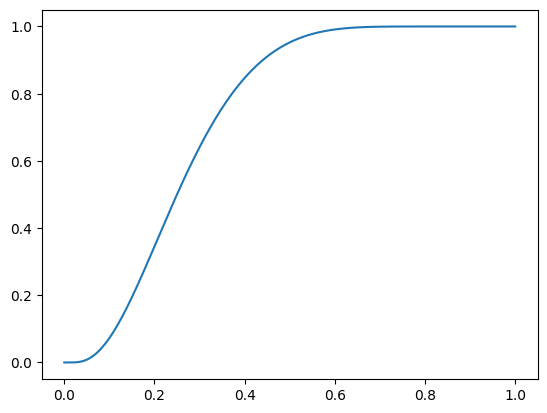

In [41]:
x = np.linspace(start=0.0001, stop=0.9999, num=1000)
y = 1/(1+np.exp(-2*3*(2*x**0.5-1)/(1-(2*x**0.5-1)**2)))
plt.plot(x,y)

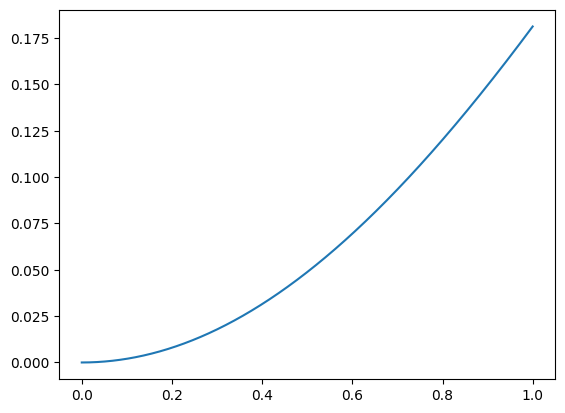

In [48]:
y=1-np.exp(-np.power(x,2)/5)
plt.plot(x,y)